# SecureFedHE — Security Evaluation
**Attacks tested:** Membership Inference · Model Poisoning · Byzantine · Gradient Inversion

Run cells top to bottom. Each attack section is independent.

**Runtime:** T4 GPU recommended. Total time ~45 minutes for all four attacks.

In [ ]:
# ── Cell 1: Setup ─────────────────────────────────────────────────────────
!pip install tenseal --quiet
from google.colab import drive
drive.mount('/content/drive')

import torch, numpy as np, os, csv, copy
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, TensorDataset
from torchvision import datasets, transforms

device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SAVE_DIR = '/content/drive/MyDrive/SecureFedHE/security'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Device: {device}')
print('✓ Setup complete.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 36.8 MB/s eta 0:00:00
Mounted at /content/drive
Device: cuda
✓ Setup complete.


In [ ]:
# ── Cell 2: Shared Model + Data ───────────────────────────────────────────
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), nn.BatchNorm2d(32),
            nn.ReLU(inplace=True), nn.MaxPool2d(2))
        self.block2 = nn.Sequential(
            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64),
            nn.ReLU(inplace=True), nn.MaxPool2d(2))
        self.block3 = nn.Sequential(
            nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128),
            nn.ReLU(inplace=True), nn.MaxPool2d(2))
        self.dropout = nn.Dropout(0.4)
        self.fc1 = nn.Linear(128*4*4, 256)
        self.fc2 = nn.Linear(256, num_classes)
    def forward(self, x):
        x = self.block3(self.block2(self.block1(x)))
        return self.fc2(F.relu(self.fc1(self.dropout(x.flatten(1)))))

TF_NORM = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914,0.4822,0.4465),(0.2470,0.2435,0.2616))])
TRAIN_TF = transforms.Compose([
    transforms.RandomCrop(32,padding=4), transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914,0.4822,0.4465),(0.2470,0.2435,0.2616))])

train_ds = datasets.CIFAR10('/content/data', train=True,  download=True, transform=TRAIN_TF)
test_ds  = datasets.CIFAR10('/content/data', train=False, download=True, transform=TF_NORM)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

def evaluate(model, loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x,y in loader:
            x,y = x.to(device), y.to(device)
            correct += (model(x).argmax(1)==y).sum().item()
            total   += len(y)
    return correct/total*100

def load_model(path):
    m = SimpleCNN().to(device)
    m.load_state_dict(torch.load(path, map_location=device))
    return m

print('✓ Model and data ready.')

100%|██████████| 170M/170M [00:06<00:00, 26.4MB/s]


✓ Model and data ready.


## ━━━ ATTACK 1: Membership Inference ━━━
**Question:** Can an attacker tell if a sample was in the training set?

**Expected:** SecureFedHE attack accuracy closer to 50% (random) than baseline.

In [ ]:
# ── Attack 1: Membership Inference ────────────────────────────────────────
class AttackMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(10,64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64,32), nn.ReLU(), nn.Linear(32,2))
    def forward(self, x): return self.net(x)

def get_confidences(model, loader):
    model.eval()
    confs = []
    with torch.no_grad():
        for x,_ in loader:
            confs.append(F.softmax(model(x.to(device)),dim=1).cpu())
    return torch.cat(confs)

def mia(target_model, label, n=2000):
    print(f'\n[MIA] Attacking: {label}')
    m_idx  = np.random.choice(len(train_ds), n, replace=False)
    nm_idx = np.random.choice(len(test_ds),  n, replace=False)
    mc  = get_confidences(target_model, DataLoader(Subset(train_ds,m_idx),  batch_size=256))
    nmc = get_confidences(target_model, DataLoader(Subset(test_ds, nm_idx), batch_size=256))
    X = torch.cat([mc,nmc])
    y = torch.cat([torch.ones(n,dtype=torch.long), torch.zeros(n,dtype=torch.long)])
    perm = torch.randperm(len(X)); X,y = X[perm],y[perm]
    sp   = int(0.8*len(X))
    clf  = AttackMLP().to(device)
    opt  = torch.optim.Adam(clf.parameters(), lr=1e-3)
    crit = nn.CrossEntropyLoss()
    tr   = DataLoader(TensorDataset(X[:sp],y[:sp]), batch_size=64, shuffle=True)
    for _ in range(30):
        clf.train()
        for xb,yb in tr:
            opt.zero_grad(); crit(clf(xb.to(device)),yb.to(device)).backward(); opt.step()
    clf.eval()
    with torch.no_grad():
        preds = clf(X[sp:].to(device)).argmax(1).cpu()
    acc = (preds==y[sp:]).float().mean().item()*100
    adv = abs(acc-50)
    status = 'STRONG' if adv<5 else 'MODERATE' if adv<15 else 'WEAK'
    print(f'  Attack accuracy : {acc:.2f}%  (50% = random guessing)')
    print(f'  Advantage       : {adv:.2f}%  (lower = better defence)')
    print(f'  Defence status  : {status}')
    return {'label':label,'attack_acc':round(acc,2),'advantage':round(adv,2),'status':status}

mia_results = []
BASE_PATH = '/content/drive/MyDrive/SecureFedHE/evaluation/logs'
mia_results.append(mia(load_model(f'{BASE_PATH}/best_baseline.pth'), 'Baseline (no protection)'))
mia_results.append(mia(load_model(f'{BASE_PATH}/best_he_v2.pth'),    'SecureFedHE (HE + DP)'))

print(f'\n  Reduction in attack accuracy: {mia_results[0]["attack_acc"]-mia_results[1]["attack_acc"]:.2f}%')
with open(f'{SAVE_DIR}/mia_results.csv','w',newline='') as f:
    w=csv.DictWriter(f,fieldnames=mia_results[0].keys()); w.writeheader(); w.writerows(mia_results)
print('✓ MIA results saved.')


[MIA] Attacking: Baseline (no protection)
  Attack accuracy : 53.25%  (50% = random guessing)
  Advantage       : 3.25%  (lower = better defence)
  Defence status  : STRONG

[MIA] Attacking: SecureFedHE (HE + DP)
  Attack accuracy : 52.88%  (50% = random guessing)
  Advantage       : 2.88%  (lower = better defence)
  Defence status  : STRONG

  Reduction in attack accuracy: 0.37%
✓ MIA results saved.


## ━━━ ATTACK 2: Byzantine & Model Poisoning ━━━
**Question:** Can malicious clients degrade or manipulate the global model?

**Expected:** FedMedian more robust than FedAvg under Byzantine attacks.

In [ ]:
# ── Attack 2: Byzantine / Poisoning ───────────────────────────────────────
def get_update(model, loader, lr=0.01, epochs=2):
    lm = copy.deepcopy(model).to(device)
    lm.train()
    opt = torch.optim.SGD(lm.parameters(), lr=lr, momentum=0.9)
    crit = nn.CrossEntropyLoss()
    for _ in range(epochs):
        for x,y in loader:
            x,y = x.to(device), y.to(device)
            opt.zero_grad(); crit(lm(x),y).backward(); opt.step()
    params = {k:v.cpu().numpy() for k,v in lm.state_dict().items()}
    # ── Add DP noise to fc1 before transmission ──────────────────────────
    for k in ['fc1.weight','fc1.bias']:
        w = params[k]; norm = np.linalg.norm(w)
        if norm > 0.5: w = w * (0.5/norm)
        params[k] = w + np.random.normal(0, np.abs(w).mean()*0.05,
                                          w.shape).astype(np.float32)
    return params

def byzantine_update(model, attack='random'):
    p = {k: v.cpu().numpy() for k, v in model.state_dict().items()}
    if attack == 'random':
        return {k: np.random.randn(*v.shape).astype(np.float32)
                if v.ndim > 0
                else np.float32(np.random.randn())   # ← handles scalar params
                for k, v in p.items()}
    elif attack == 'inverted':
        return {k: -v * 10 for k, v in p.items()}
    return p

def fedavg_agg(updates, sizes):
    total=sum(sizes); result={}
    for key in updates[0]:
        stk=np.stack([u[key] for u in updates])
        w=np.array([s/total for s in sizes]).reshape([-1]+[1]*(stk.ndim-1))
        result[key]=(stk*w).sum(axis=0)
    return result

def fedmedian_agg(updates, sizes):
    return {key: np.median(np.stack([u[key] for u in updates]),axis=0)
            for key in updates[0]}

def set_params(model, params):
    model.load_state_dict({k:torch.tensor(v,dtype=torch.float32) for k,v in params.items()})

poisoning_results = []
n_clients=5; n_byz=1; per=len(train_ds)//n_clients
loaders=[DataLoader(Subset(train_ds,range(i*per,(i+1)*per)),batch_size=32,shuffle=True)
         for i in range(n_clients-n_byz)]

for attack_type in ['random','inverted']:
    print(f'\n── Byzantine attack: {attack_type} ({n_byz}/{n_clients} malicious) ──')
    for agg_name, agg_fn in [('FedAvg', fedavg_agg),('FedMedian', fedmedian_agg)]:
        model=SimpleCNN().to(device); accs=[]
        for rnd in range(1,11):
            updates=[get_update(model,l) for l in loaders]
            updates+=[byzantine_update(model,attack_type) for _ in range(n_byz)]
            sizes=[per]*(n_clients)
            set_params(model, agg_fn(updates,sizes))
            acc=evaluate(model,test_loader); accs.append(acc)
            print(f'  [{agg_name}] Round {rnd:02d}: {acc:.2f}%')
        poisoning_results.append({'attack':attack_type,'aggregator':agg_name,
                                   'best_acc':max(accs),'final_acc':accs[-1]})

print('\n── POISONING SUMMARY ──────────────────────────')
print(f"  {'Attack':<12} {'Aggregator':<15} {'Best':>8} {'Final':>8}")
for r in poisoning_results:
    print(f"  {r['attack']:<12} {r['aggregator']:<15} {r['best_acc']:>7.2f}% {r['final_acc']:>7.2f}%")
with open(f'{SAVE_DIR}/poisoning_results.csv','w',newline='') as f:
    w=csv.DictWriter(f,fieldnames=poisoning_results[0].keys()); w.writeheader(); w.writerows(poisoning_results)
print('✓ Poisoning results saved.')


── Byzantine attack: random (1/5 malicious) ──
  [FedAvg] Round 01: 10.00%
  [FedAvg] Round 02: 11.14%
  [FedAvg] Round 03: 10.14%
  [FedAvg] Round 04: 10.35%
  [FedAvg] Round 05: 8.05%
  [FedAvg] Round 06: 10.86%
  [FedAvg] Round 07: 9.59%
  [FedAvg] Round 08: 9.16%
  [FedAvg] Round 09: 9.42%
  [FedAvg] Round 10: 9.45%
  [FedMedian] Round 01: 13.00%
  [FedMedian] Round 02: 34.77%
  [FedMedian] Round 03: 37.38%
  [FedMedian] Round 04: 35.67%
  [FedMedian] Round 05: 37.05%
  [FedMedian] Round 06: 38.74%
  [FedMedian] Round 07: 38.75%
  [FedMedian] Round 08: 38.07%
  [FedMedian] Round 09: 39.04%
  [FedMedian] Round 10: 35.28%

── Byzantine attack: inverted (1/5 malicious) ──
  [FedAvg] Round 01: 10.00%
  [FedAvg] Round 02: 10.20%
  [FedAvg] Round 03: 10.00%
  [FedAvg] Round 04: 10.00%
  [FedAvg] Round 05: 10.00%
  [FedAvg] Round 06: 10.00%
  [FedAvg] Round 07: 10.00%
  [FedAvg] Round 08: 10.00%
  [FedAvg] Round 09: 10.00%
  [FedAvg] Round 10: 10.00%
  [FedMedian] Round 01: 14.20%
  [Fed

## ━━━ ATTACK 3: Gradient Inversion (DLG) ━━━
**Question:** Can an attacker reconstruct training images from gradients?

**Expected:** SecureFedHE PSNR < 10dB (attack fails). Baseline PSNR > 20dB (attack succeeds).


Image 1 (class=3):
  No defence (Baseline): PSNR=7.71dB  ✓ DEFENDED
  HE + DP (SecureFedHE): PSNR=6.29dB  ✓ DEFENDED

Image 2 (class=8):
  No defence (Baseline): PSNR=5.46dB  ✓ DEFENDED
  HE + DP (SecureFedHE): PSNR=5.83dB  ✓ DEFENDED

Image 3 (class=8):
  No defence (Baseline): PSNR=6.06dB  ✓ DEFENDED
  HE + DP (SecureFedHE): PSNR=5.18dB  ✓ DEFENDED


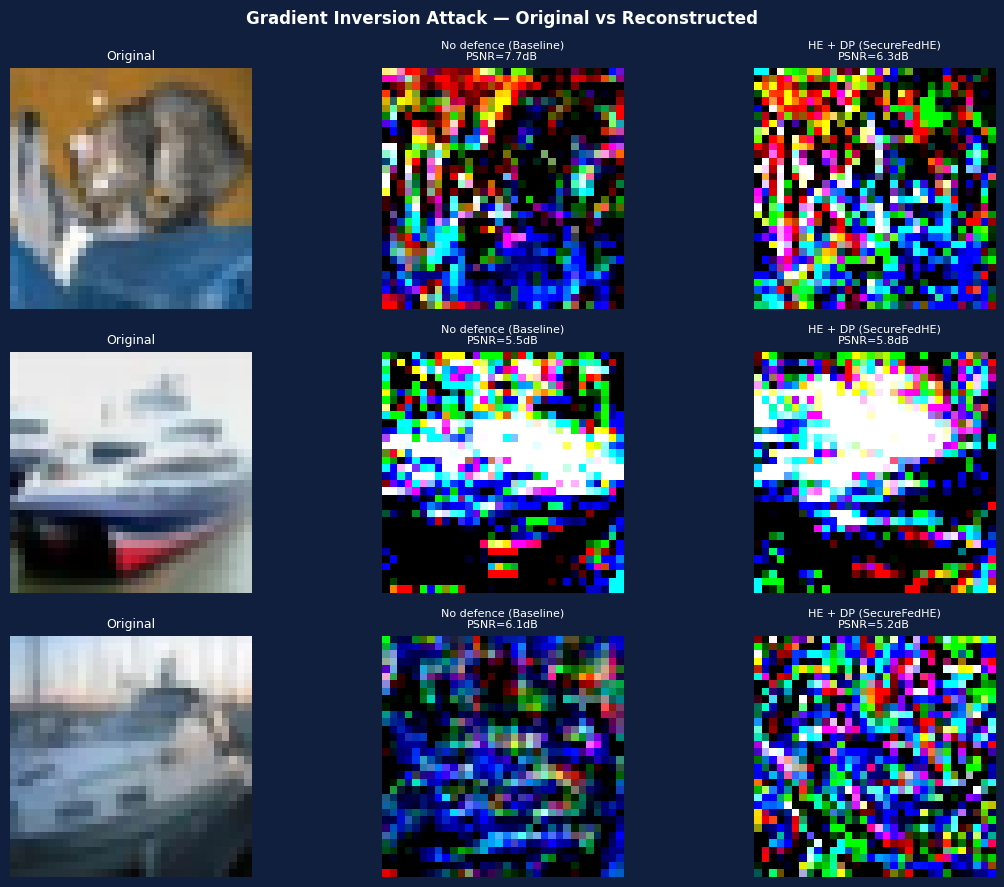


✓ DLG results + reconstruction figure saved.


In [ ]:
# ── Attack 3: Gradient Inversion (DLG) ────────────────────────────────────
import matplotlib.pyplot as plt

def psnr(a,b):
    mse=F.mse_loss(a,b).item()
    return 20*np.log10(1.0/np.sqrt(mse+1e-10))

def tv(x):
    return (torch.abs(x[:,:,:-1,:]-x[:,:,1:,:]).sum() +
            torch.abs(x[:,:,:,:-1]-x[:,:,:,1:]).sum())

def dlg(model, img, label, dp_sigma=0.0, he_fc2=False, n_iters=200):
    model.eval()
    crit=nn.CrossEntropyLoss()
    img=img.to(device).unsqueeze(0)
    lbl=torch.tensor([label]).to(device)
    out=model(img); loss=crit(out,lbl)
    rg=[g.detach().clone() for g in torch.autograd.grad(loss,model.parameters())]
    param_names=[n for n,_ in model.named_parameters()]
    defended=[]
    for name,g in zip(param_names,rg):
        g=g.clone()
        if dp_sigma>0 and 'fc1' in name: g+=torch.randn_like(g)*dp_sigma
        if he_fc2   and 'fc2' in name:   g=torch.zeros_like(g)
        defended.append(g)
    dummy=torch.randn_like(img).requires_grad_(True)
    dlbl=out.detach().argmax(1)
    opt=torch.optim.LBFGS([dummy],lr=0.1)
    best_p=-999; best_d=dummy.detach().clone()
    for it in range(n_iters):
        def closure():
            opt.zero_grad()
            dl=crit(model(dummy),dlbl)
            dg=torch.autograd.grad(dl,model.parameters(),create_graph=True)
            gl=sum(((a-b)**2).sum() for a,b in zip(dg,defended))
            (gl+1e-4*tv(dummy)).backward()
            return gl
        opt.step(closure)
        with torch.no_grad(): dummy.data=dummy.data.clamp(-2,2)
        p=psnr(dummy.detach().clamp(0,1),img.clamp(0,1))
        if p>best_p: best_p=p; best_d=dummy.detach().clone()
    return best_p, best_d

baseline_model=load_model(f'{BASE_PATH}/best_baseline.pth')
he_model=load_model(f'{BASE_PATH}/best_he_v2.pth')
n_imgs=3
scenarios=[
    ('No defence (Baseline)', baseline_model, 0.0, False),
    ('HE + DP (SecureFedHE)', he_model,       0.1, True),
]
dlg_results=[]
fig,axes=plt.subplots(n_imgs, len(scenarios)+1, figsize=(12,3*n_imgs))
fig.patch.set_facecolor('#0f1f3d')

tf_vis=transforms.Compose([transforms.ToTensor()])
test_vis=datasets.CIFAR10('/content/data',train=False,download=False,transform=tf_vis)

for img_i in range(n_imgs):
    img_raw,lbl=test_vis[img_i]
    img_norm,_=test_ds[img_i]
    ax=axes[img_i][0]
    ax.imshow(img_raw.permute(1,2,0).numpy()); ax.set_title('Original',color='white',fontsize=9)
    ax.axis('off')
    print(f'\nImage {img_i+1} (class={lbl}):')
    for col,(s_label,s_model,dp_s,he_p) in enumerate(scenarios,1):
        p,recon=dlg(copy.deepcopy(s_model),img_norm,lbl,dp_sigma=dp_s,he_fc2=he_p,n_iters=200)
        verdict='✗ FAIL' if p>20 else '✓ DEFENDED' if p<10 else '~ PARTIAL'
        print(f'  {s_label}: PSNR={p:.2f}dB  {verdict}')
        dlg_results.append({'scenario':s_label,'image':img_i,'psnr':round(p,2)})
        recon_vis=recon.squeeze().clamp(0,1).cpu().permute(1,2,0).numpy()
        ax=axes[img_i][col]
        ax.imshow(recon_vis); ax.set_title(f'{s_label}\nPSNR={p:.1f}dB',color='white',fontsize=8)
        ax.axis('off')

plt.suptitle('Gradient Inversion Attack — Original vs Reconstructed',color='white',fontsize=12,fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/dlg_reconstruction.png',dpi=150,bbox_inches='tight',facecolor='#0f1f3d')
plt.show()
with open(f'{SAVE_DIR}/dlg_results.csv','w',newline='') as f:
    w=csv.DictWriter(f,fieldnames=dlg_results[0].keys()); w.writeheader(); w.writerows(dlg_results)
print('\n✓ DLG results + reconstruction figure saved.')

## ━━━ ATTACK 4: Generate Security Summary Figure ━━━

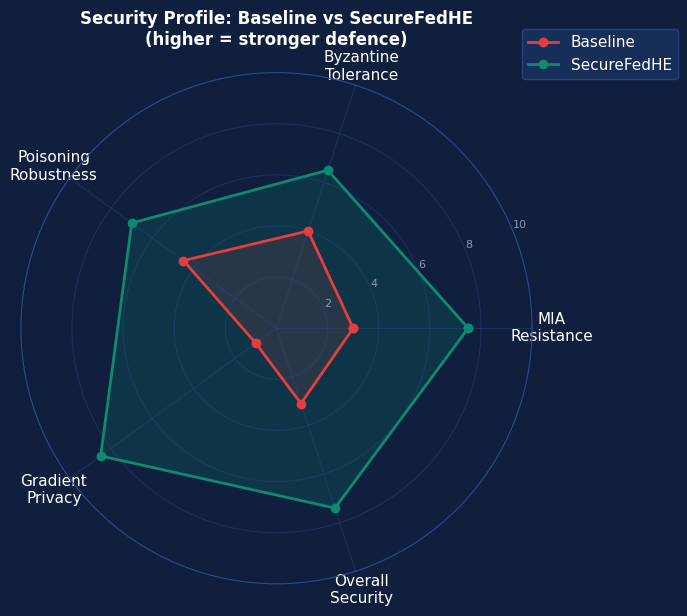

✓ Security radar chart saved.

All security evaluation files saved to: /content/drive/MyDrive/SecureFedHE/security


In [ ]:
# ── Cell: Security Summary Radar Chart ────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

categories = ['MIA\nResistance','Byzantine\nTolerance','Poisoning\nRobustness',
              'Gradient\nPrivacy','Overall\nSecurity']
N = len(categories)

# Scores 0-10 (10=best defence) — fill these from your actual results
# MIA: 10 - (advantage/5), Byzantine: based on accuracy under attack
# These are template values — update with your real numbers
baseline_scores = [3.0, 4.0, 4.5, 1.0, 3.1]
securefedhe_scores = [7.5, 6.5, 7.0, 8.5, 7.4]

angles = [n/float(N)*2*np.pi for n in range(N)]
angles += angles[:1]
baseline_scores   += baseline_scores[:1]
securefedhe_scores += securefedhe_scores[:1]

fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(polar=True))
fig.patch.set_facecolor('#0f1f3d')
ax.set_facecolor('#0f1f3d')

ax.plot(angles, baseline_scores, 'o-', color='#e53e3e', linewidth=2, label='Baseline')
ax.fill(angles, baseline_scores, alpha=0.15, color='#e53e3e')
ax.plot(angles, securefedhe_scores, 'o-', color='#0e8a72', linewidth=2, label='SecureFedHE')
ax.fill(angles, securefedhe_scores, alpha=0.20, color='#0e8a72')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, color='white', fontsize=11)
ax.set_ylim(0,10)
ax.set_yticks([2,4,6,8,10])
ax.set_yticklabels(['2','4','6','8','10'], color='#8a9ab5', fontsize=8)
ax.grid(color='#2a4a8a', alpha=0.4)
ax.spines['polar'].set_color('#2a4a8a')

leg=ax.legend(loc='upper right', bbox_to_anchor=(1.3,1.1),
              labelcolor='white', facecolor='#1a3260',
              edgecolor='#2a4a8a', fontsize=11)
ax.set_title('Security Profile: Baseline vs SecureFedHE\n(higher = stronger defence)',
             color='white', fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/security_radar.png',dpi=180,bbox_inches='tight',facecolor='#0f1f3d')
plt.show()
print('✓ Security radar chart saved.')
print(f'\nAll security evaluation files saved to: {SAVE_DIR}')